### Multi-Class classification


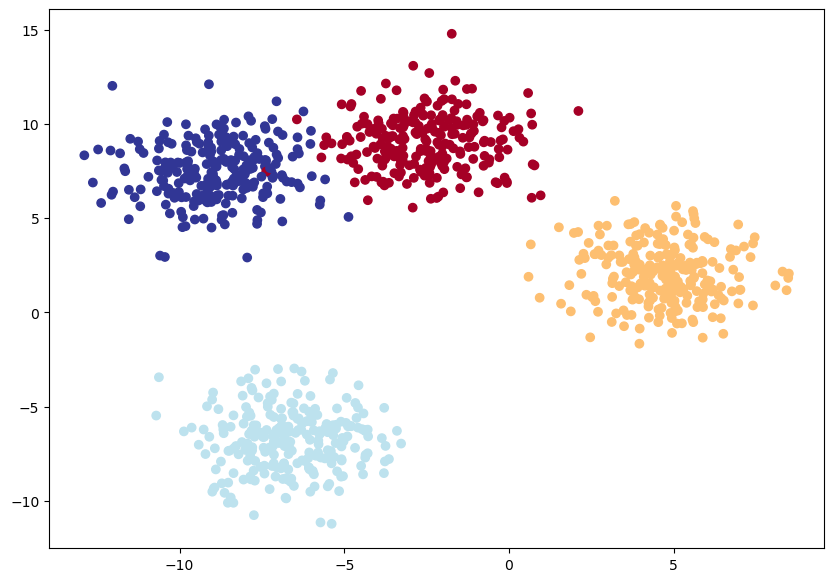

In [80]:
import torch 
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split 

# Set hyperparameters 
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42 

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples= 1000,
                            n_features= NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std = 1.5, #change this number !  
                            random_state=RANDOM_SEED)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state= RANDOM_SEED)

# 4. Plot data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:, 0], X_blob[:,1], c=y_blob, cmap=plt.cm.RdYlBu)

In [81]:
import requests 

from pathlib import Path 

# Download helper functions 
if Path("helper_functions.py").is_file():
    print("The file does exist")
else: 
    print("Download helper function")
    requests =requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open ("helper_function.py", "wb") as f:
        f.write(requests.content)
        
from helper_function import plot_predictions, plot_decision_boundary
    

Download helper function


In [82]:
def accuracy_fn (y_true, y_pred): 
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred))* 100
    return acc 

#### 2. Building a multi-class classification

In [83]:
# Create device 
device = 'cuda' if torch.cuda.is_available () else 'cpu'
device


'cpu'

In [84]:
# Build a multi-class classification model
class BlobModel(nn.Module): 
    def __init__(self, input_features, output_features, hidden_units=8) :
        ''' 
        Initiate multi-class classification model. 
        
        Args : 
            input_features (int) 
            output_features (int) : Number of output classes 
            hidden_features (int) : # Hidden units between layers 
        
        '''
        
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features= hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )
    def forward (self, x): 
        return self.linear_layer_stack(x)
    
# Create instance of BlobModel
model_0 = BlobModel(input_features=2, 
                    output_features=4,  # Number of classes 
                    hidden_units=8#by default
                    ).to(device)

model_0
    

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

### 3. Loss function and optimizer

In [85]:
# create loss function for multi-class
loss_fn = nn.CrossEntropyLoss()

#Optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr = 0.1) 



### 4. Getting predictions 

To evaluate the model : logits -> pred Probs -> Pred_labels

In [86]:
# Get logits 

model_0.eval()
with torch.inference_mode(): 
    y_logits = model_0(X_blob_test.to(device))
y_logits

tensor([[-7.6459e-01, -7.4120e-01, -1.5777e+00, -1.1376e+00],
        [-9.7256e-02, -9.4310e-01, -5.9631e-01, -1.3715e-01],
        [ 2.5277e-01, -2.3794e-01,  1.8817e-01, -6.5686e-03],
        [-4.1340e-01, -5.2042e-01, -9.3033e-01, -6.9626e-01],
        [-3.1184e-01, -1.3736e+00, -1.1991e+00, -3.8337e-01],
        [-1.4971e-01, -1.0617e+00, -7.1069e-01, -1.6452e-01],
        [ 1.5388e-01, -2.8874e-01,  1.5199e-01, -1.0874e-02],
        [-2.1543e-01, -1.1795e+00, -9.3000e-01, -2.7448e-01],
        [ 2.4432e-01, -2.4716e-01,  1.6492e-01,  6.1045e-03],
        [-2.3286e-01, -1.2120e+00, -9.8487e-01, -3.0037e-01],
        [-1.7742e-01, -1.1008e+00, -8.2929e-01, -2.3689e-01],
        [-9.4082e-01, -7.8985e-01, -1.8480e+00, -1.3347e+00],
        [-2.9723e-01, -1.3458e+00, -1.1543e+00, -3.6287e-01],
        [-2.9006e-01, -1.3393e+00, -1.1146e+00, -3.3518e-01],
        [-3.3713e-01, -1.4374e+00, -1.2379e+00, -3.8029e-01],
        [-1.0260e-01, -9.5066e-01, -6.1913e-01, -1.5105e-01],
        

#### 5. Activation 

In [87]:
# Convert model outputs to prediction probs
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])



tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]])
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]])


In [88]:
torch.sum(y_pred_probs[0]) # Softmax gives u 1 

tensor(1.0000)

In [89]:
# Conovert model prediction probs to prediction labels
y_preds = torch.argmax(y_pred_probs, dim = 1)
y_preds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1])

In [90]:
y_blob_test #same shape. That's what we need

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

#### 5. Create training/testing loop

In [91]:
# Fit the multiclass to the data

torch.manual_seed(42)

# Set number epochs 

epochs = 100

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs): 
    # Training data 
    model_0.train()
    
    y_logits = model_0(X_blob_train)
    y_pred = torch.softmax(y_logits, dim = 1).argmax(dim = 1)

    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train, 
                      y_pred=y_pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    model_0.eval()
    with torch.inference_mode(): 
        test_logits = model_0(X_blob_test)
        test_preds = torch.softmax(test_logits, dim =1).argmax(dim=1)
        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test,
                               y_pred=test_preds)
    if epoch % 10 == 0: 
        print(f' epoch : {epoch} , loss : {loss:.5f}, Acc: {acc:.2f}, test loss : {test_loss:.2f}, test acc : {test_acc:.2f}')







 epoch : 0 , loss : 1.15883, Acc: 40.38, test loss : 1.08, test acc : 48.00
 epoch : 10 , loss : 0.64476, Acc: 96.75, test loss : 0.66, test acc : 97.50
 epoch : 20 , loss : 0.42535, Acc: 98.50, test loss : 0.43, test acc : 100.00
 epoch : 30 , loss : 0.25294, Acc: 99.12, test loss : 0.25, test acc : 99.50
 epoch : 40 , loss : 0.11232, Acc: 99.25, test loss : 0.10, test acc : 99.50
 epoch : 50 , loss : 0.06627, Acc: 99.25, test loss : 0.06, test acc : 99.50
 epoch : 60 , loss : 0.05068, Acc: 99.25, test loss : 0.04, test acc : 99.50
 epoch : 70 , loss : 0.04300, Acc: 99.25, test loss : 0.03, test acc : 99.50
 epoch : 80 , loss : 0.03836, Acc: 99.25, test loss : 0.03, test acc : 99.50
 epoch : 90 , loss : 0.03525, Acc: 99.25, test loss : 0.03, test acc : 99.50


##### 6. Making/evaluating multi-class model


In [92]:
# Make predictions 
model_0.eval()
with torch.inference_mode(): 
    y_logits = model_0(X_blob_test)
    
# View first 10 predictiosn 
y_logits [:10]



tensor([[-0.6249,  5.9860, -7.6323, -8.4470],
        [-2.1738, -6.3750, -3.7202,  3.1203],
        [-3.4102, -3.8958,  3.1567, -2.6119],
        [-1.1505,  4.1962, -3.8472, -4.8820],
        [ 3.7548, -1.3391, -9.1422, -6.9466],
        [-2.8211, -7.5767, -4.2944,  3.7944],
        [-3.0306, -3.3328,  2.7955, -2.1374],
        [ 3.3761, -4.0375, -6.8987, -3.5503],
        [-4.3620, -4.9904,  3.8123, -3.3814],
        [ 3.5012, -3.0281, -7.5401, -4.7064]])

In [93]:
# From logits -> prediction probabilities 

y_pred_probs = torch.softmax(y_logits, dim = 1)
y_pred_probs [:10]
y_blob_test 

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

In [94]:
# Go from pred probs to pred labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

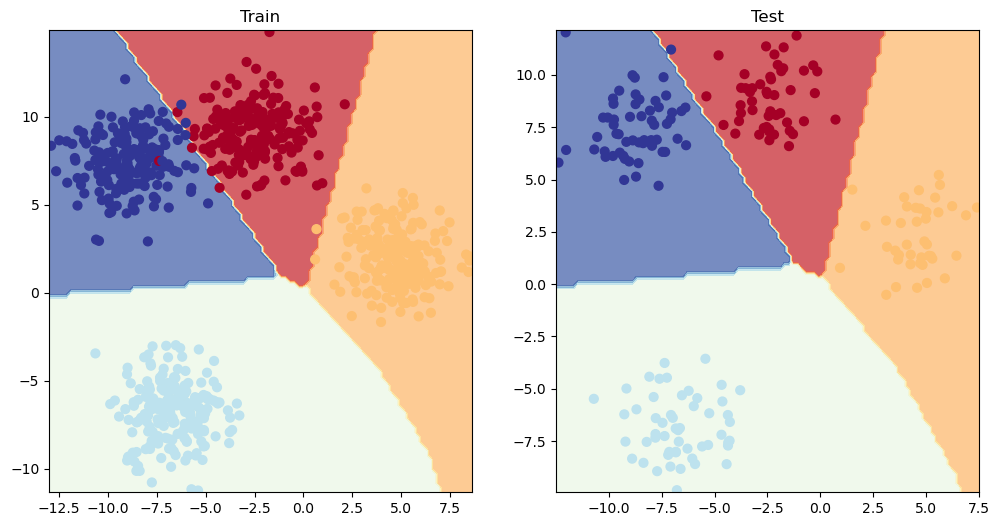

In [95]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_blob_test, y_blob_test)

#### 9. Classification metrics

In [99]:
!pip install torchmetrics


Defaulting to user installation because normal site-packages is not writeable


In [101]:
from torchmetrics import Accuracy 

torchmetric_acc = Accuracy(task="multiclass", num_classes=4).to(device)
torchmetric_acc(y_preds, y_blob_test)

tensor(0.9950)